## 원핫인코딩

### Pandas get_dummies 버전

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

In [30]:
# 1. 데이터 로드
df = pd.read_csv("dataset/tips.csv")

In [31]:
# 2. Feature Engineering
df['bill_per_person'] = df['total_bill'] / df['size']
df['is_weekend'] = df['day'].isin(['Sat','Sun']).astype(int)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)
df['tip_rate'] = df['tip'] / df['total_bill']

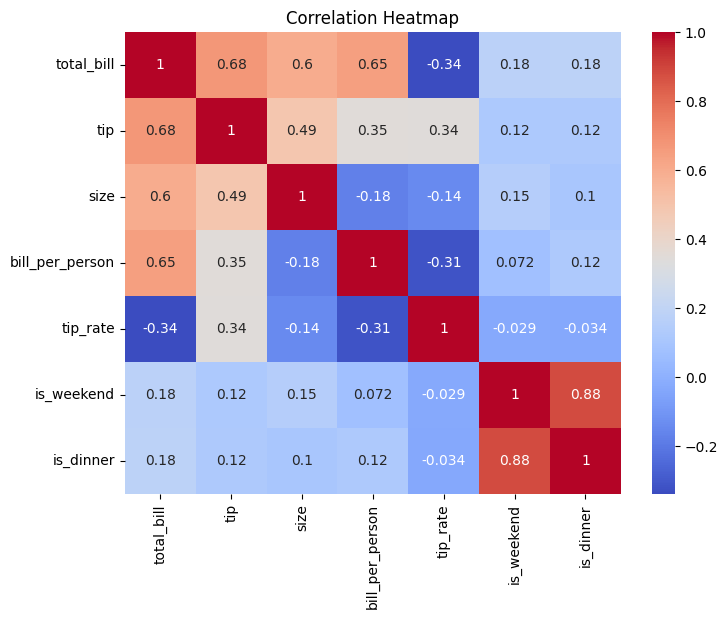

In [32]:
# 3. 히트맵
plt.figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [33]:
# 4. One-Hot Encoding (get_dummies)
categorical_cols = ['sex', 'smoker', 'day', 'time']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
# drop_first=True → 다중공선성 방지
print("\n===== One-Hot Encoding 이후 데이터 =====")
print(df.head())


===== One-Hot Encoding 이후 데이터 =====
   total_bill   tip  size  bill_per_person  is_weekend  is_dinner  tip_rate  \
0       16.99  1.01     2         8.495000           1          1  0.059447   
1       10.34  1.66     3         3.446667           1          1  0.160542   
2       21.01  3.50     3         7.003333           1          1  0.166587   
3       23.68  3.31     2        11.840000           1          1  0.139780   
4       24.59  3.61     4         6.147500           1          1  0.146808   

   sex_Male  smoker_Yes  day_Sat  day_Sun  day_Thur  time_Lunch  
0     False       False    False     True     False       False  
1      True       False    False     True     False       False  
2      True       False    False     True     False       False  
3      True       False    False     True     False       False  
4     False       False    False     True     False       False  


In [8]:
# 5. X, y 분리
X = df.drop('tip', axis=1)
y = df['tip']

In [9]:
# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# 7. 모델 학습
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=3, n_estimators=500,
                      random_state=42)

In [12]:
# 8. 평가
y_pred = model.predict(X_test)

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


===== 모델 성능 =====
R2 Score: 0.8248
RMSE: 0.4679


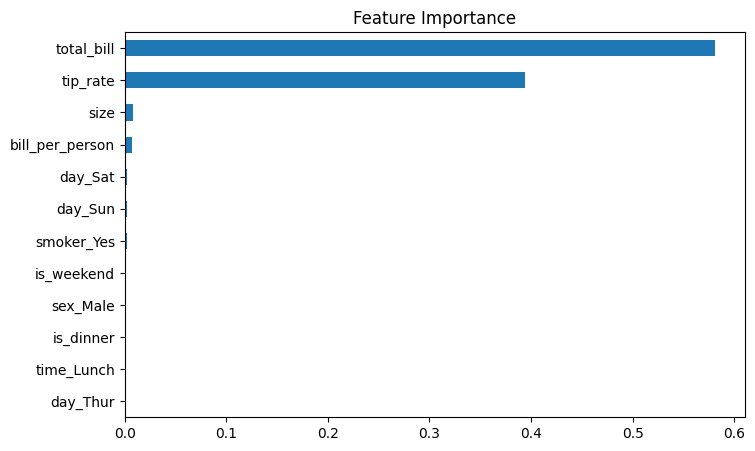

In [13]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

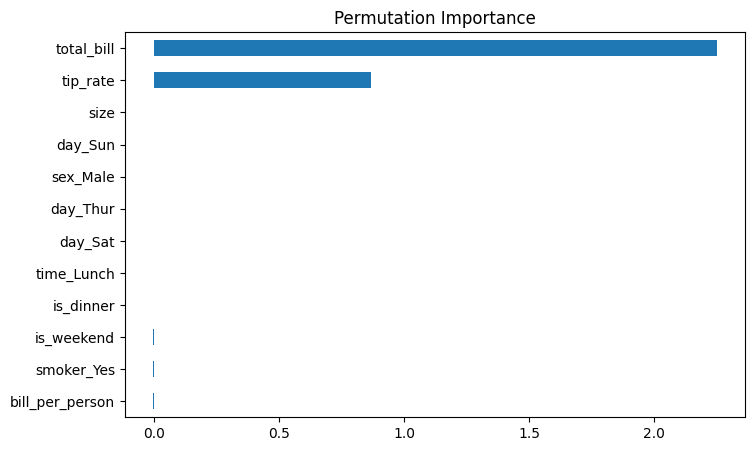

In [14]:
# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

In [ ]:
# 11. 모델 저장
joblib.dump(model, "model/tips_model02.pkl")
joblib.dump(encoders, "model/tips_labelencoders02.pkl")

### sklearn OneHotEncoder 버전

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder

In [35]:
# 1. 데이터 로드
df = pd.read_csv("dataset/tips.csv")

In [36]:
# 2. Feature Engineering
df['bill_per_person'] = df['total_bill'] / df['size']
df['is_weekend'] = df['day'].isin(['Sat','Sun']).astype(int)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)
df['tip_rate'] = df['tip'] / df['total_bill']

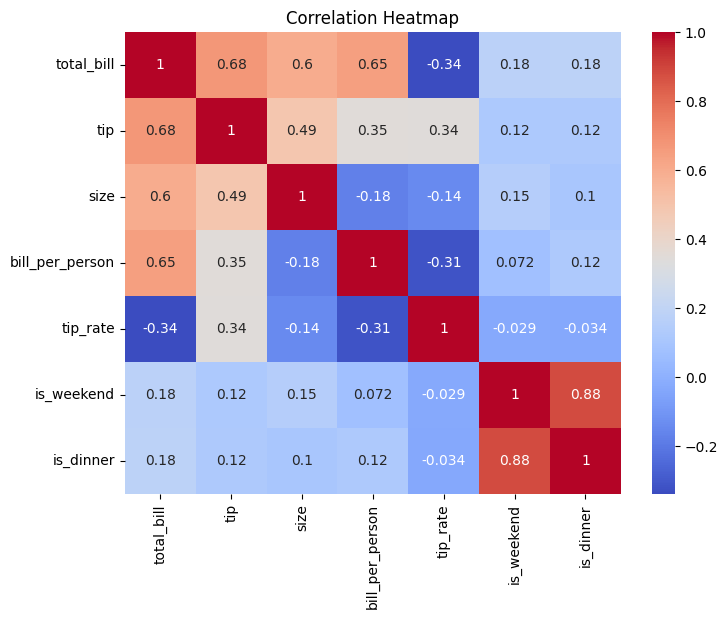

In [37]:
# 3. 히트맵
plt.figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [38]:
# 4. OneHotEncoder 적용
categorical_cols = ['sex', 'smoker', 'day', 'time']
numeric_cols = df.columns.difference(categorical_cols + ['tip'])

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

df_encoded = pd.DataFrame(encoded, columns=encoded_cols)

# 기존 숫자형 + 인코딩 합치기
df_final = pd.concat([df[numeric_cols].reset_index(drop=True),
                      df_encoded.reset_index(drop=True)], axis=1)

print("\n===== OneHotEncoder 이후 데이터 =====")
print(df_final.head())


===== OneHotEncoder 이후 데이터 =====
   bill_per_person  is_dinner  is_weekend  size  tip_rate  total_bill  \
0         8.495000          1           1     2  0.059447       16.99   
1         3.446667          1           1     3  0.160542       10.34   
2         7.003333          1           1     3  0.166587       21.01   
3        11.840000          1           1     2  0.139780       23.68   
4         6.147500          1           1     4  0.146808       24.59   

   sex_Male  smoker_Yes  day_Sat  day_Sun  day_Thur  time_Lunch  
0       0.0         0.0      0.0      1.0       0.0         0.0  
1       1.0         0.0      0.0      1.0       0.0         0.0  
2       1.0         0.0      0.0      1.0       0.0         0.0  
3       1.0         0.0      0.0      1.0       0.0         0.0  
4       0.0         0.0      0.0      1.0       0.0         0.0  


In [20]:
# 5. X, y
X = df_final
y = df['tip']

In [21]:
# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# 7. 모델 학습
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

# 8. 평가
y_pred = model.predict(X_test)

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


===== 모델 성능 =====
R2 Score: 0.8252
RMSE: 0.4674


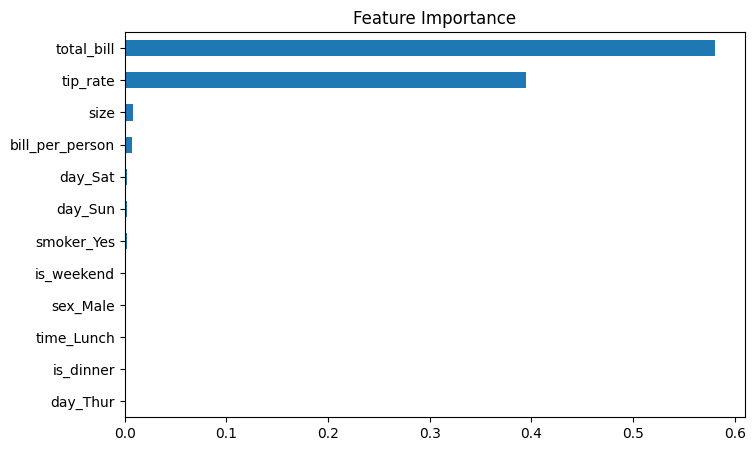

In [24]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

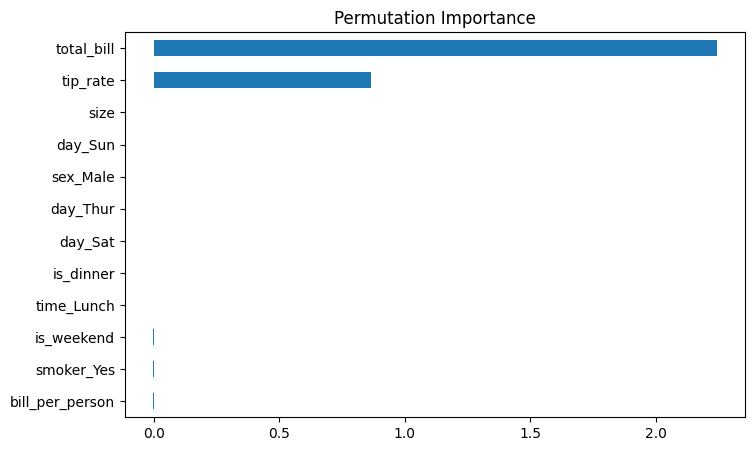

In [25]:
# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

In [ ]:
# 11. 모델 저장
joblib.dump(model, "model/tips_model02.pkl")
joblib.dump(encoders, "model/tips_labelencoders02.pkl")